# House Price Prediction Using Machine Learning

## Project Overview

This project explores how machine learning can be used to predict house prices based on different characteristics of residential areas.

Using the California Housing dataset, I explored the data, prepared the features, trained Linear Regression and Random Forest Regression models, compared their performance, analyzed feature importance, and generated a final prediction.

The project was developed using Python, Pandas, NumPy, Matplotlib, and Scikit-learn.

## Project Contents

1. Problem Statement
2. Dataset
3. Data Exploration
4. Data Preparation
5. Linear Regression
6. Random Forest Regression
7. Model Comparison
8. Feature Importance
9. Error Analysis
10. Final Prediction
11. Conclusion

## 1. Problem Statement

The goal of this project is to build machine learning models that can predict house prices based on characteristics of residential areas.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Dataset

This project uses the California Housing dataset available through Scikit-learn.

The dataset contains information about residential areas in California. The features include median income, house age, average number of rooms, average number of bedrooms, population, average household size, latitude, and longitude.

The target variable represents the median house value for each area.

In [ ]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset shape:", df.shape)
print("\nFeature columns:")
print(list(housing.feature_names))
print("\nTarget column:")
print(housing.target_names)

Dataset shape: (20640, 9)

Feature columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target column:
['MedHouseVal']


### First Look at the Dataset

In [ ]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Checking for Missing Values

In [ ]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


## 3. Data Exploration

### Basic Statistics

In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Distribution of House Values

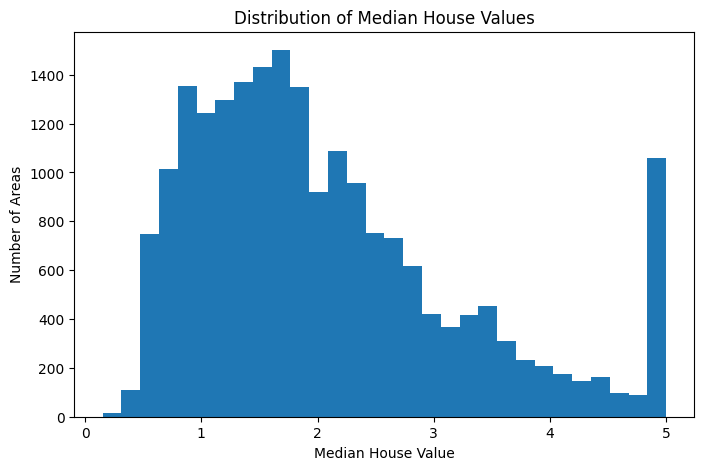

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(df["MedHouseVal"], bins=30)

plt.xlabel("Median House Value")
plt.ylabel("Number of Areas")
plt.title("Distribution of Median House Values")

plt.show()

### Correlation with House Value

In [38]:
correlations = df.corr(numeric_only=True)["MedHouseVal"].sort_values(ascending=False)

print(correlations)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


## 4. Data Preparation

The target variable is MedHouseVal, which represents the median house value.

The remaining columns are used as input features. The dataset is divided into training and testing sets so that the models can be evaluated on data they did not see during training.

In [41]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (16512, 8)
Testing features shape: (4128, 8)
Training target shape: (16512,)
Testing target shape: (4128,)


### Training Data

In [42]:
print("X_train:")
print(X_train.head())

print("\ny_train:")
print(y_train.head())

X_train:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
14196  3.2596      33.0  5.017657   1.006421      2300.0  3.691814     32.71   
8267   3.8125      49.0  4.473545   1.041005      1314.0  1.738095     33.77   
17445  4.1563       4.0  5.645833   0.985119       915.0  2.723214     34.66   
14265  1.9425      36.0  4.002817   1.033803      1418.0  3.994366     32.69   
2271   3.5542      43.0  6.268421   1.134211       874.0  2.300000     36.78   

       Longitude  
14196    -117.03  
8267     -118.16  
17445    -120.48  
14265    -117.11  
2271     -119.80  

y_train:
14196    1.030
8267     3.821
17445    1.726
14265    0.934
2271     0.965
Name: MedHouseVal, dtype: float64


## 5. Linear Regression

Linear Regression is used as a baseline model to predict house values from the selected features.

In [43]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression predictions:")
print(linear_predictions[:10])

Linear Regression predictions:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


Linear Regression predictions:
[...]

In [44]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_mse = mean_squared_error(y_test, linear_predictions)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 0.5332001304956553
MSE: 0.5558915986952444
RMSE: 0.7455813830127764
R²: 0.5757877060324508


## 6. Random Forest Regression

Random Forest Regression combines multiple decision trees to make predictions. It can capture nonlinear relationships between features and house values.

In [46]:
random_forest = RandomForestRegressor(
      n_estimators=100,
          random_state=42
          )

random_forest.fit(X_train, y_train)

rf_predictions = random_forest.predict(X_test)

print("Random Forest predictions:")
print(rf_predictions[:10])

Random Forest predictions:
[0.5095    0.74161   4.9232571 2.52961   2.27369   1.64692   2.37605
 1.66932   2.7729706 4.9134589]


### Random Forest Evaluation

In [47]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 0.32754256845930246
MSE: 0.2553684927247781
RMSE: 0.5053399773665033
R²: 0.8051230593157366


## 7. Model Comparison

The two regression models are compared using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R².

Lower MAE, MSE, and RMSE indicate smaller prediction errors, while a higher R² indicates better explanatory performance.

In [49]:
comparison = pd.DataFrame({
      "Model": ["Linear Regression", "Random Forest"],
          "MAE": [linear_mae, rf_mae],
              "MSE": [linear_mse, rf_mse],
                  "RMSE": [linear_rmse, rf_rmse],
                      "R²": [linear_r2, rf_r2]
                      })

comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.533200,0.555892,0.745581,0.575788
1,Random Forest,0.327543,0.255368,0.505340,0.805123


## 8. Feature Importance

Feature importance shows which features contributed most to the Random Forest model's predictions.

In [50]:
feature_importance = pd.DataFrame({
      "Feature": X.columns,
          "Importance": random_forest.feature_importances_
          })
feature_importance = feature_importance.sort_values(
              by="Importance",
                  ascending=False
                  )
feature_importance

,Feature,Importance
0,MedInc,0.524871
5,AveOccup,0.138443
6,Latitude,0.088936
7,Longitude,0.088629
1,HouseAge,0.054593
2,AveRooms,0.044272
4,Population,0.030650
3,AveBedrms,0.029606


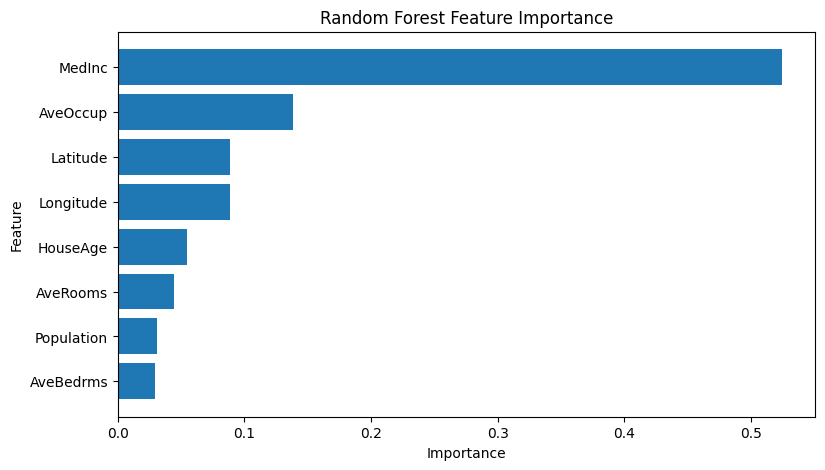

In [51]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_importance["Feature"],
        feature_importance["Importance"]
        )
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.show()

## 9. Error Analysis

Error analysis helps identify cases where the Random Forest model's predictions differ most from thge actual house values.

The absolute error measures the size of each prediction error.

In [52]:
error_analysis = pd.DataFrame({
      "Actual": y_test.values,
          "Predicted": rf_predictions
          })

error_analysis["Error"] = (
              error_analysis["Actual"] - error_analysis["Predicted"]
              )

error_analysis["Absolute_Error"] = (
                  error_analysis["Error"].abs()
                  )

error_analysis = error_analysis.sort_values(
                      by="Absolute_Error",
                          ascending=False
                          )
error_analysis.head(10)

,Actual,Predicted,Error,Absolute_Error
2927,0.17500,3.220841,-3.045841,3.045841
3693,5.00001,1.956510,3.043500,3.043500
872,5.00001,2.025551,2.974459,2.974459
285,1.25000,4.092953,-2.842953,2.842953
1649,5.00001,2.193990,2.806020,2.806020
3710,4.50000,1.699391,2.800609,2.800609
1253,5.00001,2.231750,2.768260,2.768260
429,5.00001,2.244330,2.755680,2.755680
1250,0.67500,3.400091,-2.725091,2.725091
1865,5.00001,2.425551,2.574459,2.574459


## 10. Final Prediction

The Random Forest model performed better than Linear Regression on the test data. A prediction is generated for a sample residential area from the test set.

In [53]:
sample_house = X_test.iloc[[0]]

final_prediction = random_forest.predict(sample_house)[0]

print("Predicted House Value:", round(final_prediction, 2))

Predicted House Value: 0.51


## 11. Conclusion

This project demonstrated how machine learning can be used to predict house values using residential and geographic features.

Linear Regression and Random Forest Regression were trained and evaluated using MAE, MSE, RMSE, and R². The model comparison showed which approach performed better on the test data.

The feature importance analysis provided insight into which variables contributed most to the Random Forest predictions.

Through this project, I practiced data exploration, data preparation, model training, evaluation, comparison, and interpretation of machine learning results.